# 1.15 Ensemble Learning (Bagging, Boosting, Voting, Stacking)

We use the Titanic dataset (already cleaned/preprocessed in previous notebooks).

In this lesson you will learn:
- **Bagging**: Random Forest, Extra Trees, BaggingClassifier
- **Boosting**: AdaBoost, Gradient Boosting
- **Voting**: combine different models
- **Stacking**: meta-model on top of base models

We compare models using **Accuracy** and **F1 score**.

In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Load dataset (try preprocessed first; fallback to cleaned/raw)

df = pd.read_csv('output/1.10_preprocessed_train.csv')

df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age__was_missing,Cabin__was_missing,Embarked__was_missing,...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,0,3,22.0,1.0,0,7.2500,0,1,0,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.0,1.0,0,65.6344,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.0,0.0,0,7.9250,0,1,0,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.0,1.0,0,53.1000,0,0,0,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.0,0.0,0,8.0500,0,1,0,...,False,False,False,False,False,False,False,False,False,True


In [25]:
df.shape, df.columns[:15].tolist()

((891, 1732),
 ['PassengerId',
  'Survived',
  'Pclass',
  'Age',
  'SibSp',
  'Parch',
  'Fare',
  'Age__was_missing',
  'Cabin__was_missing',
  'Embarked__was_missing',
  'AgeGroup',
  'FamilySize',
  'LogFare',
  'Name_Abbott, Mr. Rossmore Edward',
  'Name_Abbott, Mrs. Stanton (Rosa Hunt)'])

## Step 1 — Prepare X and y
We use `Survived` as the target (classification). We also remove ID columns like `PassengerId`.

In [26]:
# Detect target
target_candidates = ['Survived', 'target', 'Target', 'label', 'y']
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError('No target column found. Expected Survived.')

# Remove ID-like columns
id_cols = [c for c in ['PassengerId', 'CustomerID', 'CustomerId', 'ID', 'Id'] if c in df.columns]

X = df.drop(columns=[target_col] + id_cols).copy()
y = df[target_col].copy()

# If there are categorical columns (raw train.csv), one-hot encode
if X.select_dtypes(exclude=[np.number, bool]).shape[1] > 0:
    X = pd.get_dummies(X, drop_first=True)

# Convert booleans to 0/1
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(int)

if y.dtype == bool:
    y = y.astype(int)

# Simple missing handling
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts().to_dict()

((712, 1732), (179, 1732), {0: 439, 1: 273})

## Helper — Evaluate a model
We keep evaluation simple: Accuracy and F1 score.

In [27]:
def evaluate_classifier(model, name=None):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    avg = 'binary' if y_test.nunique() == 2 else 'weighted'
    return {
        'model': name if name is not None else model.__class__.__name__,
        'accuracy': float(accuracy_score(y_test, preds)),
        'f1': float(f1_score(y_test, preds, average=avg)),
    }

## Bagging
Bagging trains many models on bootstrap samples, then combines their predictions.

Examples: Random Forest, Extra Trees, BaggingClassifier.

In [28]:
results = []

# Baselines (not ensembles, but good references)
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=2000)
results.append(evaluate_classifier(dt, 'DecisionTree (baseline)'))
results.append(evaluate_classifier(lr, 'LogisticRegression (baseline)'))

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

results.append(evaluate_classifier(rf, 'RandomForest (bagging)'))
results.append(evaluate_classifier(et, 'ExtraTrees (bagging)'))
results.append(evaluate_classifier(bag_dt, 'Bagging + DecisionTree'))

pd.DataFrame(results).sort_values(['accuracy', 'f1'], ascending=False)

,model,accuracy,f1
1,LogisticRegression (baseline),0.821229,0.757576
3,ExtraTrees (bagging),0.815642,0.759124
4,Bagging + DecisionTree,0.776536,0.682540
0,DecisionTree (baseline),0.770950,0.666667
2,RandomForest (bagging),0.765363,0.681818


## Boosting
Boosting builds models sequentially (each new model corrects previous errors).

Examples: AdaBoost, GradientBoosting, HistGradientBoosting.

In [29]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200,
    learning_rate=0.8,
    random_state=42
)
gb = GradientBoostingClassifier(random_state=42)
hgb = HistGradientBoostingClassifier(random_state=42)

results.append(evaluate_classifier(ada, 'AdaBoost'))
results.append(evaluate_classifier(gb, 'GradientBoosting'))
results.append(evaluate_classifier(hgb, 'HistGradientBoosting'))

pd.DataFrame(results).sort_values(['accuracy', 'f1'], ascending=False)

,model,accuracy,f1
1,LogisticRegression (baseline),0.821229,0.757576
3,ExtraTrees (bagging),0.815642,0.759124
7,HistGradientBoosting,0.810056,0.738462
6,GradientBoosting,0.798883,0.689655
5,AdaBoost,0.793296,0.725926
4,Bagging + DecisionTree,0.776536,0.682540
0,DecisionTree (baseline),0.770950,0.666667
2,RandomForest (bagging),0.765363,0.681818


## Voting and Stacking
Voting combines different models (soft voting averages probabilities).
Stacking trains a meta-model on top of base model predictions.

In [30]:
rf_small = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
gb_small = GradientBoostingClassifier(random_state=42)

voting_soft = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf_small), ('gb', gb_small)],
    voting='soft'
)
results.append(evaluate_classifier(voting_soft, 'Voting (soft)'))

stack = StackingClassifier(
    estimators=[('rf', rf_small), ('gb', gb_small), ('lr', lr)],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=False,
    n_jobs=-1
)
results.append(evaluate_classifier(stack, 'Stacking'))

results_df = pd.DataFrame(results).sort_values(['accuracy', 'f1'], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,f1
0,LogisticRegression (baseline),0.821229,0.757576
1,ExtraTrees (bagging),0.815642,0.759124
2,HistGradientBoosting,0.810056,0.738462
3,Voting (soft),0.798883,0.714286
4,GradientBoosting,0.798883,0.689655
5,AdaBoost,0.793296,0.725926
6,Stacking,0.793296,0.708661
7,Bagging + DecisionTree,0.776536,0.682540
8,DecisionTree (baseline),0.770950,0.666667
9,RandomForest (bagging),0.765363,0.681818


## Best model (detailed evaluation)
We retrain the best model and show a classification report + confusion matrix.

In [31]:
best_name = results_df.loc[0, 'model']
best_name

'LogisticRegression (baseline)'

Accuracy: 0.8212290502793296
F1: 0.7575757575757576

Classification report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



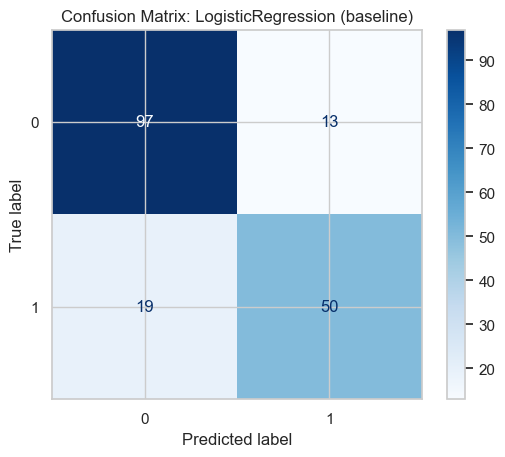

In [32]:
name_to_model = {
    'DecisionTree (baseline)': dt,
    'LogisticRegression (baseline)': lr,
    'RandomForest (bagging)': rf,
    'ExtraTrees (bagging)': et,
    'Bagging + DecisionTree': bag_dt,
    'AdaBoost': ada,
    'GradientBoosting': gb,
    'HistGradientBoosting': hgb,
    'Voting (soft)': voting_soft,
    'Stacking': stack,
}

best_model = name_to_model[best_name]
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

avg = 'binary' if y_test.nunique() == 2 else 'weighted'
print('Accuracy:', accuracy_score(y_test, best_preds))
print('F1:', f1_score(y_test, best_preds, average=avg))
print('\nClassification report:\n')
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {best_name}')
plt.show()

## (Optional) Feature importance (Random Forest)
Random Forest gives a simple feature importance score.

In [33]:
try:
    _ = rf.feature_importances_
except Exception:
    rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

Sex_male              0.117802
LogFare               0.056034
Fare                  0.055012
Age                   0.048116
Pclass                0.035583
Cabin_B96 B98         0.025174
FamilySize            0.025031
Cabin__was_missing    0.024805
SibSp                 0.018566
Parch                 0.016195
Embarked_S            0.013203
AgeGroup_Child        0.010384
AgeGroup_Young        0.007750
Age__was_missing      0.005932
Embarked_Q            0.005579
dtype: float64

### Summary
- Bagging reduces variance
- Boosting reduces bias
- Voting is an easy ensemble
- Stacking can be strong but more complex